In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import SDP_miRNA.simulation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

In [2]:
rng = np.random.default_rng(949)

## Loading

In [ ]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("../TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("../TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("../TotalX_HEK293T_capture.txt")

## Validate capture method

In [7]:
beta_mean = 0.2
total_cell_counts = np.array(adata_pcRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta_20 = np.array(total_cell_counts / total_counts_mean) * beta_mean
beta_20[beta_20 >= 1] = beta_20[beta_20 < 1].max()
beta_20[beta_20 <= 0] = beta_20[beta_20 > 0].min()

In [10]:
np.allclose(beta, beta_20)

True

## Total cell count correspondance over RNA type

Strong correlation between total counts of miRNA and pcRNA (mRNA) in each cell. Supports the choice to use the same capture efficiency (estimated from pcRNA total cell counts) for both RNA types.

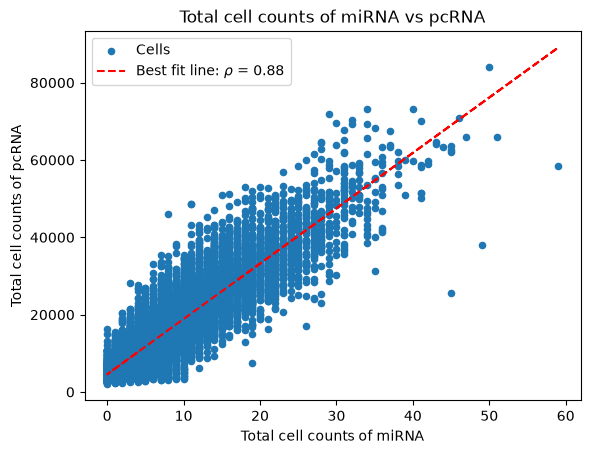

In [33]:
# total cell counts of miRNA and pcRNA
total_cell_counts_miRNA = np.array(adata_miRNA.X.sum(axis=1)).flatten()
total_cell_counts_pcRNA = np.array(adata_pcRNA.X.sum(axis=1)).flatten()

# correlation
corr = np.corrcoef(total_cell_counts_miRNA, total_cell_counts_pcRNA)[0, 1]

# display
fig, axs = plt.subplots()
axs.scatter(total_cell_counts_miRNA, total_cell_counts_pcRNA, s=20, label="Cells")

# line of best fit
z = np.polyfit(total_cell_counts_miRNA, total_cell_counts_pcRNA, 1)
p = np.poly1d(z)
axs.plot(total_cell_counts_miRNA, p(total_cell_counts_miRNA), linestyle="--", color="red", label=rf"Best fit line: $\rho$ = {round(corr, 2)}")

axs.set_xlabel("Total cell counts of miRNA")
axs.set_ylabel("Total cell counts of pcRNA")
axs.set_title("Total cell counts of miRNA vs pcRNA")
axs.legend()
plt.show()

Means that, while estimating per cell capture using just 40 miRNA per cell may have high variability, there is a strong correlation to those estimated from 10,000 pcRNA per cell (due to the total cell count correlation, which is rescaled to give capture estimate)

In [34]:
beta_mean = 0.2

In [35]:

total_cell_counts = np.array(adata_pcRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta_pcRNA = np.array(total_cell_counts / total_counts_mean) * beta_mean
beta_pcRNA[beta_pcRNA >= 1] = beta_pcRNA[beta_pcRNA < 1].max()
beta_pcRNA[beta_pcRNA <= 0] = beta_pcRNA[beta_pcRNA > 0].min()

In [36]:
total_cell_counts = np.array(adata_miRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta_miRNA = np.array(total_cell_counts / total_counts_mean) * beta_mean
beta_miRNA[beta_miRNA >= 1] = beta_miRNA[beta_miRNA < 1].max()
beta_miRNA[beta_miRNA <= 0] = beta_miRNA[beta_miRNA > 0].min()

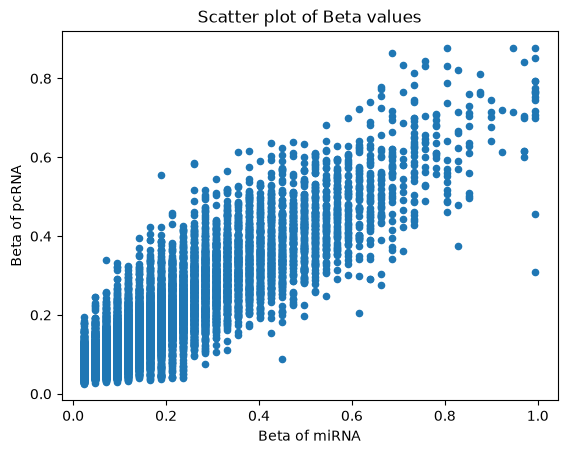

In [39]:
plt.scatter(beta_miRNA, beta_pcRNA, s=20)
plt.xlabel("Beta of miRNA")
plt.ylabel("Beta of pcRNA")
plt.title("Scatter plot of Beta values")
plt.show()